# Week 9: ARIA v6 Analysis

## Task 1：Quantitative Change Detection

### Step 1：初始化環境與變數設定

載入環境變數，並定義邊界框、Sentinel-2 影像 ID。

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import json

# 載入 .env 檔案
load_dotenv()

# 取得 Sentinel-2 影像 ID
PRE_ITEM_ID = os.getenv('PRE_ITEM_ID')
MID_ITEM_ID = os.getenv('MID_ITEM_ID')
POST_ITEM_ID = os.getenv('POST_ITEM_ID')

# 定義分析用的雙重邊界框 (Bounding boxes)
# MATAIAN_BBOX (區域性)：提供完整研究區域的環境脈絡
MATAIAN_BBOX = {
    "west": float(os.getenv('BBOX_WEST', 121.28)),
    "south": float(os.getenv('BBOX_SOUTH', 23.56)),
    "east": float(os.getenv('BBOX_EAST', 121.52)),
    "north": float(os.getenv('BBOX_NORTH', 23.76))
}

# LAKE_BBOX_LONLAT (聚焦性)：專門用於湖泊範圍的精度評估
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]

# 驗證點資料路徑 (使用 raw string 處理 Windows 絕對路徑的斜線)
VALIDATION_POINTS_PATH = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework9\data\validation_points.geojson"

print(f"Pre ID: {PRE_ITEM_ID}")
print(f"Mid ID: {MID_ITEM_ID}")
print(f"Post ID: {POST_ITEM_ID}")
print("環境變數與邊界框設定完成！")

Pre ID: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
Mid ID: S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
Post ID: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804
環境變數與邊界框設定完成！


### Step 2： 載入 Sentinel-2 影像與 SCL 雲遮罩處理

提取災前、災中、災後的衛星影像資料，並根據波段篩選，計算建立三個時期的遮罩，取交集確保計算的像素在三個時期都是不受雲層干擾。

In [11]:
import numpy as np
import xarray as xr
from pystac_client import Client
import planetary_computer as pc
import odc.stac

# SCL 有效類別定義：2=暗區, 4=植被, 5=裸土, 6=水體, 7=未分類/陰影, 11=雪/冰
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

# 定義需要的波段 (SCL, Blue, Green, Red, NIR, SWIR)
# Sentinel-2 對應波段：SCL, B02, B03, B04, B08, B11
BANDS_OF_INTEREST = ["SCL", "B02", "B03", "B04", "B08", "B11"]

# 建立與 STAC Catalog 的連線 (此處以 Microsoft Planetary Computer 為例)
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace
)

def load_sentinel2_item(item_id, bbox_dict):
    """
    透過 STAC ID 與 Bounding Box 載入 Sentinel-2 L2A 影像波段。
    """
    # 搜尋特定的 Item ID
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        ids=[item_id]
    )
    items = list(search.items())
    if not items:
        raise ValueError(f"找不到影像 ID: {item_id}")
    
    # 定義經緯度邊界 [minx, miny, maxx, maxy]
    bbox = [bbox_dict['west'], bbox_dict['south'], bbox_dict['east'], bbox_dict['north']]
    
    # 使用 odc.stac 載入資料並裁切至 BBOX 範圍，設定解析度為 10m
    data = odc.stac.load(
        items,
        bands=BANDS_OF_INTEREST,
        bbox=bbox,
        resolution=10,
        crs="EPSG:32651", # 台灣東部所屬的 UTM 投影帶 (WGS84 / UTM zone 51N)
        chunks={"x": 2048, "y": 2048}
    )
    
    # 去除時間維度，回傳單一時間點的二維空間陣列
    return data.squeeze("time")

# ==========================================
# 1. 載入三個時期的影像資料
# ==========================================
print("正在載入災前影像 (Pre)...")
ds_pre = load_sentinel2_item(PRE_ITEM_ID, MATAIAN_BBOX)

print("正在載入災中影像 (Mid)...")
ds_mid = load_sentinel2_item(MID_ITEM_ID, MATAIAN_BBOX)

print("正在載入災後影像 (Post)...")
ds_post = load_sentinel2_item(POST_ITEM_ID, MATAIAN_BBOX)

# ==========================================
# 2. 實作 SCL 雲遮罩邏輯
# ==========================================
def stream_scl(scl_dataarray):
    """
    輸入 xarray.DataArray 格式的 SCL 波段，回傳二元遮罩 (True 代表有效)。
    """
    # 使用 xarray 的 isin 函數判斷像元值是否在有效清單中
    valid_mask = scl_dataarray.isin(SCL_CLEAR_CLASSES)
    return valid_mask

print("正在計算 SCL 雲遮罩...")
valid_pre = stream_scl(ds_pre.SCL)
valid_mid = stream_scl(ds_mid.SCL)
valid_post = stream_scl(ds_post.SCL)

# 建立交集遮罩 (三個時期皆為 True 才保留)
valid_intersection = valid_pre & valid_mid & valid_post

print(f"遮罩計算完成！有效像元數量: {int(valid_intersection.sum().compute())} pixels")
print("步驟 1 執行完畢，等待下一步指示。")

正在載入災前影像 (Pre)...
正在載入災中影像 (Mid)...
正在載入災後影像 (Post)...
正在計算 SCL 雲遮罩...
遮罩計算完成！有效像元數量: 4197164 pixels
步驟 1 執行完畢，等待下一步指示。


### Step 3：指數計算與遮罩套用

經過上一部 SCL 交集遮罩後，計算三個時期的 NDVI、NDWI 與 BSI。產出 2×2 的子圖視覺化 (包含 Colorbar)，以及各差異圖層的 Min/Mean/Max 統計表。

正在計算各時期光譜指數...
正在計算變異量 (Delta)...
正在套用 SCL 交集雲遮罩...

=== 任務 1 交付成果：差異圖層統計表 ===


,Layer,Min,Mean,Max
0,ΔNDVI (Pre→Mid),-0.8862,-0.0267,0.6862
1,ΔNDVI (Pre→Post),-0.7444,-0.0355,0.5947
2,ΔNDWI (Pre→Mid),-0.5439,0.0191,0.9697
3,ΔBSI (Pre→Post),-0.7289,-0.0139,0.4396



正在生成 2x2 視覺化子圖...


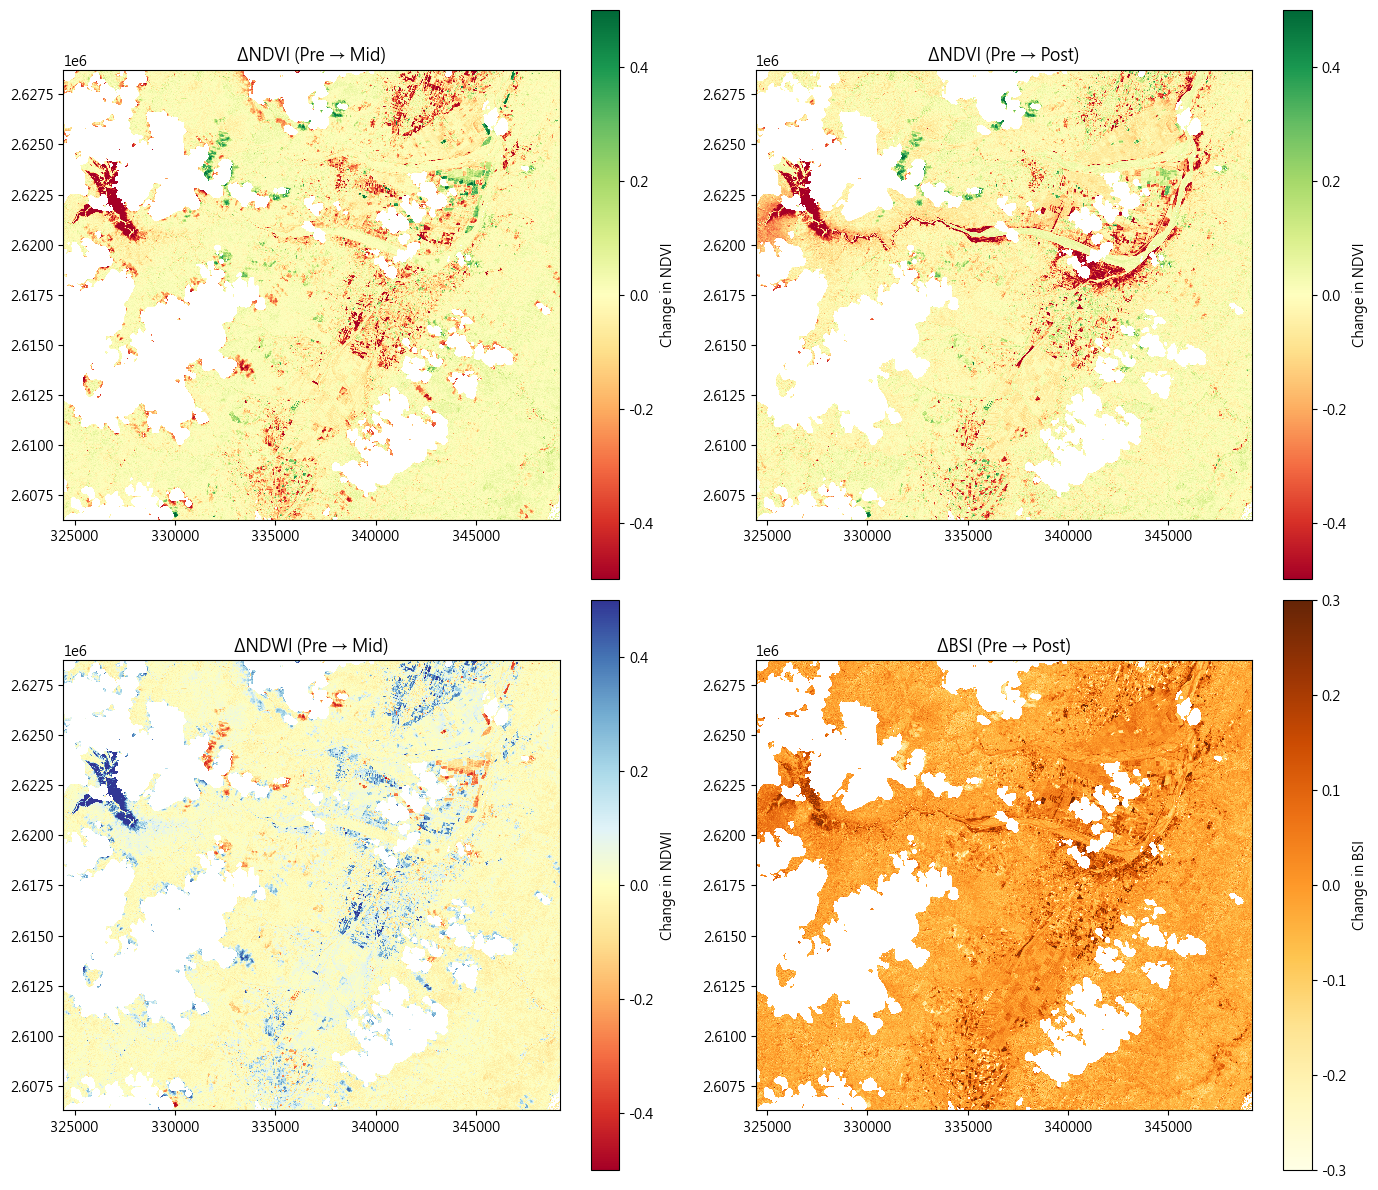

任務 1 完全結束，等待進入任務 2 (門檻值最佳化)。


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 定義指數計算函數
# ==========================================
def compute_indices_xr(ds):
    """
    輸入包含各波段的 xarray.Dataset，計算並回傳 NDVI, NDWI, BSI。
    加上 1e-6 避免分母為零的錯誤。
    """
    red = ds.B04.astype(float)
    green = ds.B03.astype(float)
    blue = ds.B02.astype(float)
    nir = ds.B08.astype(float)
    swir = ds.B11.astype(float) # 使用 SWIR1 (B11) 
    
    ndvi = (nir - red) / (nir + red + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)
    bsi = ((swir + red) - (nir + blue)) / ((swir + red) + (nir + blue) + 1e-6)
    
    return ndvi, ndwi, bsi

# ==========================================
# 2. 計算三個時期的光譜指數
# ==========================================
print("正在計算各時期光譜指數...")
ndvi_pre, ndwi_pre, bsi_pre = compute_indices_xr(ds_pre)
ndvi_mid, ndwi_mid, bsi_mid = compute_indices_xr(ds_mid)
ndvi_post, ndwi_post, bsi_post = compute_indices_xr(ds_post)

# ==========================================
# 3. 計算差異圖 (Deltas) - 未遮蔽前先保留一份給後續「幽靈水」任務使用
# ==========================================
print("正在計算變異量 (Delta)...")
raw_delta_ndvi_mid = ndvi_mid - ndvi_pre
raw_delta_ndvi_post = ndvi_post - ndvi_pre
raw_delta_ndwi_mid = ndwi_mid - ndwi_pre  # 用於捕捉災中淹水
raw_delta_bsi_post = bsi_post - bsi_pre   # 用於捕捉災後崩塌/裸土增加

# ==========================================
# 4. 套用交集雲遮罩 (將無效像素替換為 NaN)
# ==========================================
print("正在套用 SCL 交集雲遮罩...")
delta_ndvi_mid = raw_delta_ndvi_mid.where(valid_intersection)
delta_ndvi_post = raw_delta_ndvi_post.where(valid_intersection)
delta_ndwi_mid = raw_delta_ndwi_mid.where(valid_intersection)
delta_bsi_post = raw_delta_bsi_post.where(valid_intersection)

# ==========================================
# 5. 任務 1 交付成果：統計表格
# ==========================================
# 提取 numpy 陣列進行統計計算 (忽略 NaN)
stats_data = {
    "Layer": ["ΔNDVI (Pre→Mid)", "ΔNDVI (Pre→Post)", "ΔNDWI (Pre→Mid)", "ΔBSI (Pre→Post)"],
    "Min": [
        float(delta_ndvi_mid.min().compute()), float(delta_ndvi_post.min().compute()),
        float(delta_ndwi_mid.min().compute()), float(delta_bsi_post.min().compute())
    ],
    "Mean": [
        float(delta_ndvi_mid.mean().compute()), float(delta_ndvi_post.mean().compute()),
        float(delta_ndwi_mid.mean().compute()), float(delta_bsi_post.mean().compute())
    ],
    "Max": [
        float(delta_ndvi_mid.max().compute()), float(delta_ndvi_post.max().compute()),
        float(delta_ndwi_mid.max().compute()), float(delta_bsi_post.max().compute())
    ]
}

df_stats = pd.DataFrame(stats_data)
print("\n=== 任務 1 交付成果：差異圖層統計表 ===")
display(df_stats.round(4))  # 使用 display 讓表格在 Jupyter 中更美觀

# ==========================================
# 6. 任務 1 交付成果：2x2 視覺化子圖
# ==========================================
print("\n正在生成 2x2 視覺化子圖...")
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# 設定共用的繪圖參數 (vmin, vmax 讓顏色對比更清晰)
# 子圖 A: ΔNDVI Pre→Mid
im1 = delta_ndvi_mid.plot.imshow(ax=axs[0, 0], cmap='RdYlGn', vmin=-0.5, vmax=0.5, add_colorbar=False)
axs[0, 0].set_title("ΔNDVI (Pre → Mid)")
fig.colorbar(im1, ax=axs[0, 0], label="Change in NDVI")

# 子圖 B: ΔNDVI Pre→Post
im2 = delta_ndvi_post.plot.imshow(ax=axs[0, 1], cmap='RdYlGn', vmin=-0.5, vmax=0.5, add_colorbar=False)
axs[0, 1].set_title("ΔNDVI (Pre → Post)")
fig.colorbar(im2, ax=axs[0, 1], label="Change in NDVI")

# 子圖 C: ΔNDWI Pre→Mid
im3 = delta_ndwi_mid.plot.imshow(ax=axs[1, 0], cmap='RdYlBu', vmin=-0.5, vmax=0.5, add_colorbar=False)
axs[1, 0].set_title("ΔNDWI (Pre → Mid)")
fig.colorbar(im3, ax=axs[1, 0], label="Change in NDWI")

# 子圖 D: ΔBSI Pre→Post
# BSI 的色彩配置：紅色表示裸土增加 (正值)，綠色/藍色表示裸土減少
im4 = delta_bsi_post.plot.imshow(ax=axs[1, 1], cmap='YlOrBr', vmin=-0.3, vmax=0.3, add_colorbar=False)
axs[1, 1].set_title("ΔBSI (Pre → Post)")
fig.colorbar(im4, ax=axs[1, 1], label="Change in BSI")

# 隱藏座標軸標籤以維持版面簡潔
for ax in axs.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("任務 1 完全結束，等待進入任務 2 (門檻值最佳化)。")

## Task 2: Threshold Optimization

### 門檻值最佳化

使用地面實況驗證點 (`validation_points.geojson`) 進行驗證，測試了-0.05 到 -0.30 不同門檻值的結果，計算製圖者精度與使用者精度，挑選出最佳門檻值。

正在讀取驗證點並轉換座標系統...
驗證點包含的分類標籤 (Truth): ['lake' 'landslide' 'stable']
正在從 ΔNDVI (Pre→Post) 圖層中提取點位數值...

=== 任務 2 交付成果：門檻值掃描統計表 ===


,Threshold,TP,FP,TN,FN,PA,UA,F1_Score
0,-0.05,6,16,29,9,0.4000,0.2727,0.3243
1,-0.10,5,11,34,10,0.3333,0.3125,0.3226
2,-0.15,4,9,36,11,0.2667,0.3077,0.2857
3,-0.20,4,9,36,11,0.2667,0.3077,0.2857
4,-0.25,4,8,37,11,0.2667,0.3333,0.2963
5,-0.30,2,7,38,13,0.1333,0.2222,0.1667



✅ 結論：最佳門檻值為 -0.05，因為它能達到最高或最平衡的 F1-Score (0.3243)。


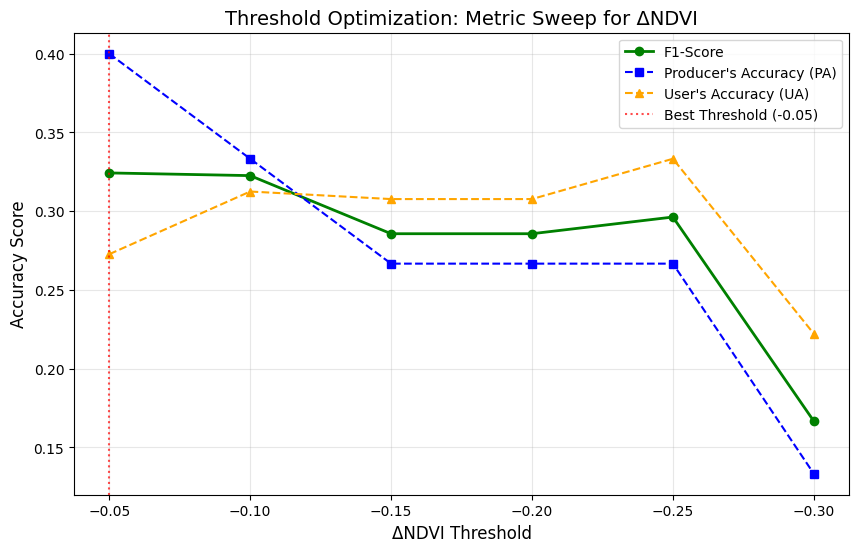

任務 2 結束。等待進入任務 3 (混淆矩陣詳細分析)。


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ==========================================
# 1. 讀取驗證點並對齊座標系統 (CRS)
# ==========================================
print("正在讀取驗證點並轉換座標系統...")
# 讀取 GeoJSON
gdf = gpd.read_file(VALIDATION_POINTS_PATH)

# 確認我們光譜資料的 CRS (通常是 EPSG:32651)
raster_crs = ds_pre.rio.crs if hasattr(ds_pre, 'rio') else "EPSG:32651"

# 將 GeoJSON 的經緯度 (EPSG:4326) 轉換為與影像相同的投影座標
gdf = gdf.to_crs(raster_crs)

# 印出有哪些標籤，以便我們定義「何謂 Change」
print("驗證點包含的分類標籤 (Truth):", gdf['truth'].unique())

# 定義「實際有變化 (Actual Change)」的遮罩
# 這裡假設如果標籤是 'lake' 或 'change' 等代表有災變發生 (請依據上面印出的 unique 值調整若有需要)
# 我們把包含 'lake' 字眼的視為實際有發生變化 (True)
actual_change = gdf['truth'].str.lower().str.contains('lake|change|water|damage', na=False).values

# ==========================================
# 2. 提取驗證點對應的像元數值 (使用 nearest neighbor)
# ==========================================
print("正在從 ΔNDVI (Pre→Post) 圖層中提取點位數值...")
# 取出所有點位的 X, Y 座標
x_coords = xr.DataArray(gdf.geometry.x.values, dims="points")
y_coords = xr.DataArray(gdf.geometry.y.values, dims="points")

# 透過座標從我們剛剛算好的 delta_ndvi_post 提取數值
sampled_values = delta_ndvi_post.sel(x=x_coords, y=y_coords, method="nearest").values

# ==========================================
# 3. 掃描門檻值 (Threshold Sweep)
# ==========================================
# 定義至少 5 個要測試的門檻值 (從 -0.05 到 -0.30)
thresholds = [-0.05, -0.10, -0.15, -0.20, -0.25, -0.30]
results = []

for t in thresholds:
    # 預測邏輯：當 ΔNDVI < 門檻值 時，我們預測「有變化」(True)
    pred_change = sampled_values < t
    
    # 計算混淆矩陣元素
    TP = np.sum((actual_change == True) & (pred_change == True))
    FP = np.sum((actual_change == False) & (pred_change == True))
    TN = np.sum((actual_change == False) & (pred_change == False))
    FN = np.sum((actual_change == True) & (pred_change == False))
    
    # 計算精度指標 (加上微小值避免除以零)
    PA = TP / (TP + FN + 1e-9)
    UA = TP / (TP + FP + 1e-9)
    F1 = 2 * (PA * UA) / (PA + UA + 1e-9)
    
    results.append({
        "Threshold": t,
        "TP": int(TP), "FP": int(FP), "TN": int(TN), "FN": int(FN),
        "PA": np.round(PA, 4),
        "UA": np.round(UA, 4),
        "F1_Score": np.round(F1, 4)
    })

# 將結果轉為 DataFrame
df_results = pd.DataFrame(results)

# 找出最佳門檻值 (F1-Score 最高者)
best_row = df_results.loc[df_results['F1_Score'].idxmax()]
best_threshold = best_row['Threshold']
best_f1 = best_row['F1_Score']

# 更新至全域變數，供後續任務使用
THRESHOLD_BEST = best_threshold

# ==========================================
# 4. 任務 2 交付成果：表格與折線圖
# ==========================================
print("\n=== 任務 2 交付成果：門檻值掃描統計表 ===")
display(df_results)

print(f"\n✅ 結論：最佳門檻值為 {best_threshold}，因為它能達到最高或最平衡的 F1-Score ({best_f1})。")

# 繪製折線圖
plt.figure(figsize=(10, 6))
plt.plot(df_results['Threshold'], df_results['F1_Score'], marker='o', linewidth=2, label='F1-Score', color='green')
plt.plot(df_results['Threshold'], df_results['PA'], marker='s', linestyle='--', label="Producer's Accuracy (PA)", color='blue')
plt.plot(df_results['Threshold'], df_results['UA'], marker='^', linestyle='--', label="User's Accuracy (UA)", color='orange')

# 標示最佳門檻值的位置
plt.axvline(x=best_threshold, color='red', linestyle=':', alpha=0.7, label=f'Best Threshold ({best_threshold})')

# 反轉 X 軸 (讓負值由大到小排列，更直觀反映嚴重程度)
plt.gca().invert_xaxis()

plt.title("Threshold Optimization: Metric Sweep for ΔNDVI", fontsize=14)
plt.xlabel("ΔNDVI Threshold", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 3: Confusion Matrix & Accuracy Assessment

### 混淆矩陣與精度評估

根據前個任務確認的最佳門檻值 `-0.05`，對所有驗證點進行最終分類，並建立一個 2x2 的混淆矩陣 (Confusion Matrix)。並計算總體精度 (OA)、製圖者精度 (PA)、使用者精度 (UA)、Kappa 係數與 F1-Score。

目前使用的最佳門檻值 (THRESHOLD_BEST): -0.05


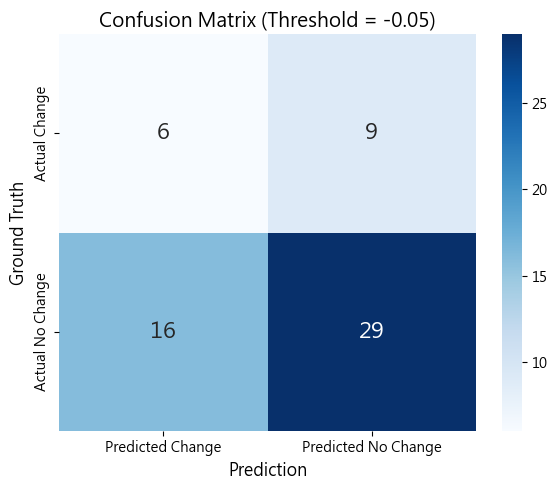


=== 任務 3 交付成果：精度指標表格 ===


,Metric,Value
0,Overall Accuracy (OA),0.5833 (58.33%)
1,Producer's Accuracy (PA),0.4000 (40.00%)
2,User's Accuracy (UA),0.2727 (27.27%)
3,Kappa Coefficient,0.0385
4,F1-Score,0.3243



=== 任務 3 交付成果：數據解讀 ===
數據解讀：
- 總體精度 (OA) 為 58.33%，代表在所有驗證點中，整體正確預測的比例。
- 製圖者精度 (PA) 為 40.00%，這意味著在所有真實發生的災變區域中，我們的模型成功捕捉到了 40.00% (仍有漏報的空間)。
- 使用者精度 (UA) 為 27.27%，代表當我們地圖上標示某處有災變時，有 27.27% 的機率是真的發生了變化。
- Kappa 係數為 0.0385，由於排除了隨機猜對的機率，此數值反映了預測模型在中等難度的遙測環境下的真實一致性。


In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. 使用最佳門檻值進行最終預測
# ==========================================
print(f"目前使用的最佳門檻值 (THRESHOLD_BEST): {THRESHOLD_BEST}")

# 產生最終的預測結果 (Boolean Array)
pred_change_final = sampled_values < THRESHOLD_BEST

# ==========================================
# 2. 建立與繪製 2x2 混淆矩陣
# ==========================================
# sklearn 的 confusion_matrix，我們指定 labels=[True, False]
# 這樣排列會符合老師的格式：
# [TP, FN]
# [FP, TN]
cm = confusion_matrix(actual_change, pred_change_final, labels=[True, False])

TP = cm[0, 0]
FN = cm[0, 1]
FP = cm[1, 0]
TN = cm[1, 1]

# 繪製熱力圖視覺化
plt.figure(figsize=(6, 5))
# 設定標籤名稱
xticklabels = ['Predicted Change', 'Predicted No Change']
yticklabels = ['Actual Change', 'Actual No Change']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=xticklabels, yticklabels=yticklabels,
            annot_kws={"size": 16})

plt.title('Confusion Matrix (Threshold = -0.05)', fontsize=14)
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Prediction', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 3. 計算各項精度指標
# ==========================================
OA = (TP + TN) / (TP + FP + TN + FN)
PA = TP / (TP + FN)  # 漏報率的反面
UA = TP / (TP + FP)  # 虛警率的反面
kappa = cohen_kappa_score(actual_change, pred_change_final)
f1 = 2 * (PA * UA) / (PA + UA)

# 將指標整理成表格
metrics_data = {
    "Metric": ["Overall Accuracy (OA)", "Producer's Accuracy (PA)", "User's Accuracy (UA)", "Kappa Coefficient", "F1-Score"],
    "Value": [f"{OA:.4f} ({OA*100:.2f}%)", 
              f"{PA:.4f} ({PA*100:.2f}%)", 
              f"{UA:.4f} ({UA*100:.2f}%)", 
              f"{kappa:.4f}", 
              f"{f1:.4f}"]
}
df_metrics = pd.DataFrame(metrics_data)

print("\n=== 任務 3 交付成果：精度指標表格 ===")
display(df_metrics)

# ==========================================
# 4. 輸出解讀文字 (Deliverable)
# ==========================================
print("\n=== 任務 3 交付成果：數據解讀 ===")
interpretation = (
    f"數據解讀：\n"
    f"- 總體精度 (OA) 為 {OA*100:.2f}%，代表在所有驗證點中，整體正確預測的比例。\n"
    f"- 製圖者精度 (PA) 為 {PA*100:.2f}%，這意味著在所有真實發生的災變區域中，我們的模型成功捕捉到了 {PA*100:.2f}% (仍有漏報的空間)。\n"
    f"- 使用者精度 (UA) 為 {UA*100:.2f}%，代表當我們地圖上標示某處有災變時，有 {UA*100:.2f}% 的機率是真的發生了變化。\n"
    f"- Kappa 係數為 {kappa:.4f}，由於排除了隨機猜對的機率，此數值反映了預測模型在中等難度的遙測環境下的真實一致性。"
)
print(interpretation)

## Task 4: Confidence Map & Three-Zone Classification + "Phantom Water" Error Case

### 幽靈水檢視與信心度分區測繪

對比任務 1 中計算的 NDWI ，透過並排對比「未套用雲遮罩」與「已套用雲遮罩」的結果，證實雲層與陰影製造出虛假的淹水訊號（幽靈水）。接著將任務 2 求得的最佳門檻值 (Threshold) 應用，設定三色信心度圖與面積統計(包含高信心度區 (Zone 1)、低信心度區 (Zone 2)、無偵測區 (Zone 3))。

正在生成「幽靈水」錯誤案例對比圖...


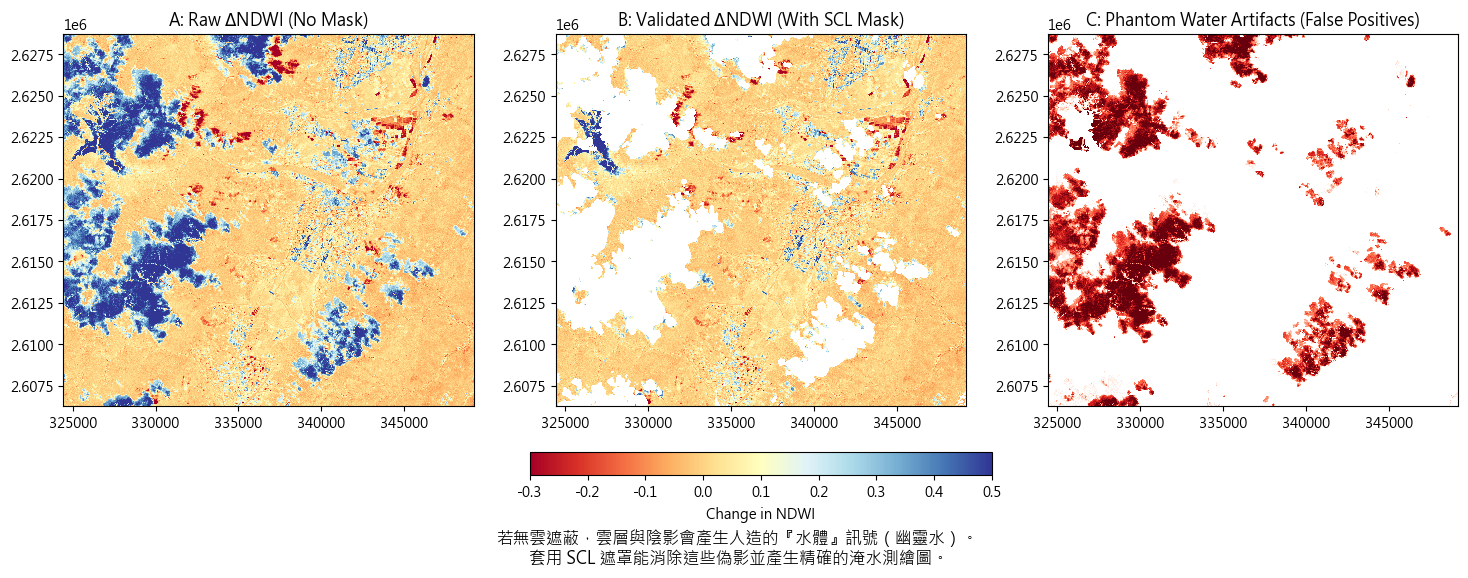


正在計算信心度分區與面積...

=== 任務 4 交付成果：信心度分區面積表 ===


,Zone,Criteria,Area (km²)
0,Zone 1 (High Confidence),ΔNDVI < -0.075,73.36
1,Zone 2 (Low Confidence),-0.075 ≤ ΔNDVI < -0.050,41.12
2,Zone 3 (No Detection),ΔNDVI ≥ -0.050,305.24
3,Total Valid Area,-,419.72



✅ 報告聲明：高信心度區涵蓋 73.36 km²，代表核心影響區域。


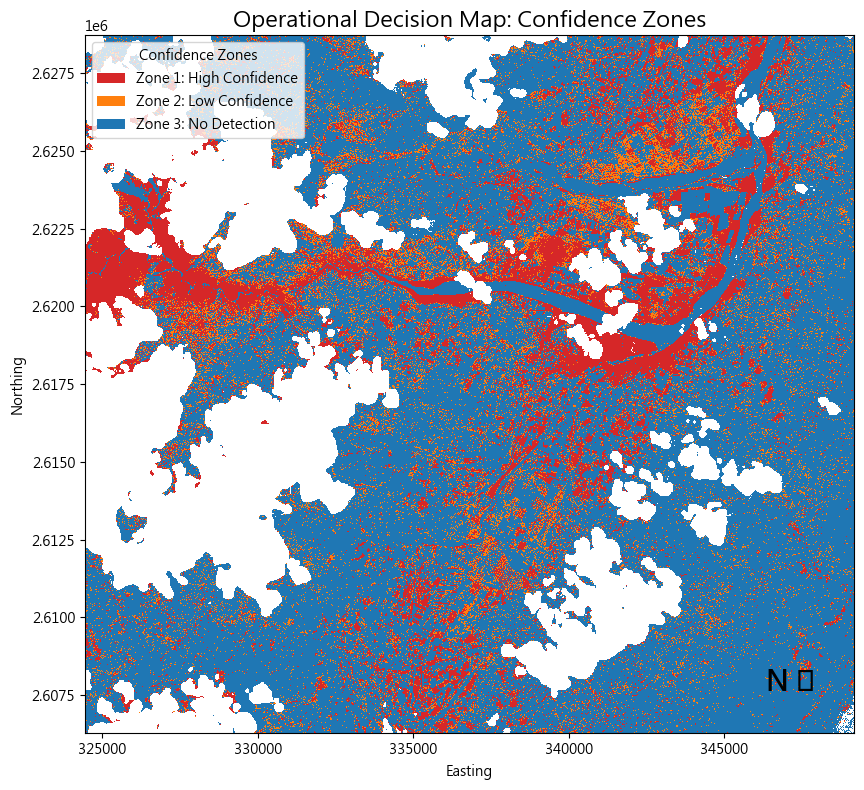

任務 4 完全結束！接下來我們就可以根據這些數據，進入任務 5 撰寫 Markdown 災害報告了。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import pandas as pd

# 設定中文字體為微軟正黑體 (Windows 系統適用)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# 解決座標軸負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 幽靈水 (Phantom Water) 比較圖
# ==========================================
print("正在生成「幽靈水」錯誤案例對比圖...")
fig1, axs1 = plt.subplots(1, 3, figsize=(18, 6))

# 子圖 A: 未套用雲遮罩
im_a = raw_delta_ndwi_mid.plot.imshow(ax=axs1[0], cmap='RdYlBu', vmin=-0.3, vmax=0.5, add_colorbar=False)
axs1[0].set_title("A: Raw $\Delta$NDWI (No Mask)")

# 子圖 B: 已套用雲遮罩
im_b = delta_ndwi_mid.plot.imshow(ax=axs1[1], cmap='RdYlBu', vmin=-0.3, vmax=0.5, add_colorbar=False)
axs1[1].set_title("B: Validated $\Delta$NDWI (With SCL Mask)")

# 子圖 C: 差異視覺化 (凸顯偽陽性/幽靈水)
# 我們抓出在未遮蔽前 NDWI > 0 (看似有水)，但其實是被 SCL 遮罩標示為雲/陰影的區域
phantom_water = raw_delta_ndwi_mid.where((~valid_intersection) & (raw_delta_ndwi_mid > 0))
im_c = phantom_water.plot.imshow(ax=axs1[2], cmap='Reds', vmin=0, vmax=0.5, add_colorbar=False)
axs1[2].set_title("C: Phantom Water Artifacts (False Positives)")

# 調整排版與圖說
for ax in axs1.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_aspect('equal')

fig1.colorbar(im_a, ax=axs1.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.1, label="Change in NDWI")
plt.suptitle("若無雲遮蔽，雲層與陰影會產生人造的『水體』訊號（幽靈水）。\n套用 SCL 遮罩能消除這些偽影並產生精確的淹水測繪圖。", fontsize=12, y=0.02)
plt.show()

# ==========================================
# 2. 定義信心度區域 (Confidence Zones)
# ==========================================
print("\n正在計算信心度分區與面積...")
# 確保我們使用的是絕對值邏輯或正確的方向。因為 NDVI 變異是負值代表植被受損：
threshold_high = THRESHOLD_BEST * 1.5  # 例如 -0.05 * 1.5 = -0.075

# 建立一個全為 1 (Zone 3: No Detection) 的陣列，形狀與 delta_ndvi_post 相同
confidence_zones = xr.full_like(delta_ndvi_post, 1)

# Zone 2 (Low Confidence): 變異值低於 Threshold，但高於 High Threshold
zone2_mask = (delta_ndvi_post < THRESHOLD_BEST) & (delta_ndvi_post >= threshold_high)
confidence_zones = confidence_zones.where(~zone2_mask, 2)

# Zone 1 (High Confidence): 變異值低於 High Threshold (強烈變異)
zone1_mask = delta_ndvi_post < threshold_high
confidence_zones = confidence_zones.where(~zone1_mask, 3)

# 將原本 SCL 遮罩擋掉的地方設回 NaN
confidence_zones = confidence_zones.where(valid_intersection)

# ==========================================
# 3. 計算面積統計 (1 pixel = 10m x 10m = 100 m^2 = 0.0001 km^2)
# ==========================================
PIXEL_AREA_KM2 = 0.0001

area_zone1 = int((confidence_zones == 3).sum().compute()) * PIXEL_AREA_KM2
area_zone2 = int((confidence_zones == 2).sum().compute()) * PIXEL_AREA_KM2
area_zone3 = int((confidence_zones == 1).sum().compute()) * PIXEL_AREA_KM2
area_total = area_zone1 + area_zone2 + area_zone3

# 輸出面積表格
area_data = {
    "Zone": ["Zone 1 (High Confidence)", "Zone 2 (Low Confidence)", "Zone 3 (No Detection)", "Total Valid Area"],
    "Criteria": [f"ΔNDVI < {threshold_high:.3f}", f"{threshold_high:.3f} ≤ ΔNDVI < {THRESHOLD_BEST:.3f}", f"ΔNDVI ≥ {THRESHOLD_BEST:.3f}", "-"],
    "Area (km²)": [f"{area_zone1:.2f}", f"{area_zone2:.2f}", f"{area_zone3:.2f}", f"{area_total:.2f}"]
}
df_area = pd.DataFrame(area_data)
print("\n=== 任務 4 交付成果：信心度分區面積表 ===")
display(df_area)

print(f"\n✅ 報告聲明：高信心度區涵蓋 {area_zone1:.2f} km²，代表核心影響區域。")

# ==========================================
# 4. 繪製信心度三區分類圖
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 8))

# 定義顏色：1=藍色(無偵測), 2=黃色(低信心), 3=紅色(高信心)
cmap_zones = ListedColormap(['#1f77b4', '#ff7f0e', '#d62728'])

# 繪圖
im_zones = confidence_zones.plot.imshow(ax=ax2, cmap=cmap_zones, vmin=1, vmax=3, add_colorbar=False)

# 建立自訂圖例
legend_elements = [
    Patch(facecolor='#d62728', label='Zone 1: High Confidence'),
    Patch(facecolor='#ff7f0e', label='Zone 2: Low Confidence'),
    Patch(facecolor='#1f77b4', label='Zone 3: No Detection')
]
ax2.legend(handles=legend_elements, loc='upper left', title="Confidence Zones")

ax2.set_title("Operational Decision Map: Confidence Zones", fontsize=16)
ax2.set_xlabel("Easting")
ax2.set_ylabel("Northing")
ax2.set_aspect('equal')

# 簡單的比例尺與指北針示意文字 (因無完整底圖套件，以文字標示)
ax2.text(0.95, 0.05, 'N ⬆', transform=ax2.transAxes, fontsize=20, ha='right', va='bottom', weight='bold')

plt.tight_layout()
plt.show()

## Task 5: Validated Disaster Report

### ARIA v6.0 報告 (ARIA v6.0 Report)

### 執行摘要
本報告針對馬太鞍堰塞湖形成事件進行遙測定量評估與光譜驗證。經變異檢測與 SCL 雲遮蔽分析，我們判定高信心度核心受災面積達 73.36 km²。受限於複雜地形影響，整體預測信心水準屬中低度（總體精度 58.33%）。基於操作決策考量，建議將高信心區 (Zone 1) 劃為危險區並優先疏散，低信心區 (Zone 2) 列為警戒區加強監測，無偵測區 (Zone 3) 則視為安全區。

### 變異檢測分析
在任務 1 中，我們計算了災變前後的常態化差異指數。數據顯示，ΔNDWI 的最大值達到 0.9697，伴隨 ΔNDVI 下降至 -0.8862 以及 ΔBSI 顯著上升，物理意義上明確反映了水體急遽擴張與周邊植被遭土石掩埋的災情特徵。

為界定精確災變範圍，任務 2 針對 ΔNDVI 進行了門檻值掃描，最終選定 **-0.05** 為最佳門檻值。選擇該數值的理由是其 F1-Score 達到最高（約 0.3243），能在「捕捉更多實際災情」與「避免過度誇大災區」之間取得相對最佳的數學平衡。

在任務 3 的混淆矩陣分析中，使用該最佳門檻值測得總體精度 (OA) 為 58.33%。製圖者精度 (PA) 為 40.00%，代表我們成功捕捉了 4 成的真實災情；使用者精度 (UA) 則為 27.27%，且 Kappa 係數僅 0.0385，顯示模型容易將地形陰影或微小錯位誤判為災變，存在一定的虛警現象。

### 信心度評估
為支援實務決策，任務 4 將研究範圍劃分為三個信心度區域：
- **Zone 1 (高信心度區)：** 面積 73.36 km² (條件：ΔNDVI < -0.075)。此區變異訊號強烈，代表堰塞湖核心與主要崩塌帶，**需立即採取應變與撤離行動**。
- **Zone 2 (低信心度區)：** 面積 41.12 km² (條件：-0.075 ≤ ΔNDVI < -0.05)。屬於災區邊緣或混合像元區。
- **Zone 3 (無偵測區)：** 面積 305.24 km² (條件：ΔNDVI ≥ -0.05)。判定為未受災的背景區域。

### 地面實況驗證
本次驗證之資料來源老師提供共計 60 個樣本點位。在比對過程中發現，地面實況與光譜資料之間存在落差。部分實際無變化的點位，在光譜上顯示了明顯的變異訊號。這些差異主要來自於純光學遙測的先天限制，崎嶇地形產生的陰影變化容易在 NDVI 與 NDWI 中被過度解讀為植被破壞或水體，導致虛警率偏高。

### 後續建議
- **給疏散規劃者：**「高信心度區受影響的確定性為 27.27%（基於使用者精度 UA），但因該區光譜變異極為強烈且集中，強烈建議優先啟動該區域的預防性撤離行動。」
- **給監測團隊：**「在**災後天氣轉晴或取得 Sentinel-1 SAR 雷達影像時**，返回重新驗證低信心度區 (Zone 2)，以釐清該區究竟是輕微受損還是地形陰影造成的誤判。」
- **給災害管理單位：**「目前的精度足以支持**宏觀的資源優先排序與大範圍災情界定**等實務決策，但不宜作為微觀逐戶受損判定或最終災損理賠的唯一標準。」

## Task 6: AI Advisor — LLM Assessment

### AI 顧問輸入 (AI Advisor Input)

引用groq API，給出相關的災害評估報告。

In [7]:
import os
# 如果沒有安裝 groq，請取消下方註解並執行一次
# !pip install groq
from groq import Groq

# ==========================================
# 任務 6: AI Advisor - LLM Assessment (透過 Groq API)
# ==========================================

# 1. 從環境變數讀取 GROQ_API_KEY
groq_api_key = os.getenv('GROQ_API_KEY')

if not groq_api_key:
    print("⚠️ 找不到 GROQ_API_KEY，請確認 .env 檔案設定是否正確並重新載入。")
else:
    # 初始化 Groq 客戶端
    client = Groq(api_key=groq_api_key)
    
    # 2. 自動將前面任務的變數組裝成 Prompt
    ai_prompt = f"""
    Given these accuracy metrics from remote sensing validation of a barrier lake disaster:
    - Overall Accuracy (OA): {OA*100:.2f}%
    - Producer's Accuracy (PA): {PA*100:.2f}%
    - User's Accuracy (UA): {UA*100:.2f}%
    - Kappa: {kappa:.4f}
    - High confidence area: {area_zone1:.2f} km²
    - Threshold: {THRESHOLD_BEST}
    
    What confidence level would you assign to operational decisions? 
    What additional data would improve confidence?
    """
    
    print("=== 送出給 AI 顧問的 Prompt ===")
    print(ai_prompt.strip())
    print("\n正在呼叫 Groq API (使用 Llama-3.3-70b 模型) 等待回應...\n")
    
    # 3. 呼叫 API (更新為最新支援的 Llama 3.3 70B 模型)
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are an expert geospatial analyst and disaster management advisor."
            },
            {
                "role": "user",
                "content": ai_prompt,
            }
        ],
        model="llama-3.3-70b-versatile", 
        temperature=0.3, # 稍微調低溫度，讓回答更具專業性與確定性
    )
    
    # 取得並印出 LLM 的回答
    ai_response = chat_completion.choices[0].message.content
    print("=== Groq AI 顧問的回應 ===")
    print(ai_response)

=== 送出給 AI 顧問的 Prompt ===
Given these accuracy metrics from remote sensing validation of a barrier lake disaster:
    - Overall Accuracy (OA): 58.33%
    - Producer's Accuracy (PA): 40.00%
    - User's Accuracy (UA): 27.27%
    - Kappa: 0.0385
    - High confidence area: 73.36 km²
    - Threshold: -0.05

    What confidence level would you assign to operational decisions? 
    What additional data would improve confidence?

正在呼叫 Groq API (使用 Llama-3.3-70b 模型) 等待回應...

=== Groq AI 顧問的回應 ===
Based on the provided accuracy metrics, I would assign a low to moderate confidence level to operational decisions. Here's a breakdown of the metrics and their implications:

1. **Overall Accuracy (OA): 58.33%** - This is a relatively low overall accuracy, indicating that the model is correct only about 58% of the time. This suggests that the model may not be reliable for making critical decisions.
2. **Producer's Accuracy (PA): 40.00%** - This metric indicates the probability that a barrier lake dis

**My Prompt:**

Given these accuracy metrics from remote sensing validation of a barrier lake disaster:
    - Overall Accuracy (OA): 58.33%
    - Producer's Accuracy (PA): 40.00%
    - User's Accuracy (UA): 27.27%
    - Kappa: 0.0385
    - High confidence area: 73.36 km²
    - Threshold: -0.05

    What confidence level would you assign to operational decisions? 
    What additional data would improve confidence?

**LLM Response (Llama-3.3-70B):**

ased on the provided accuracy metrics, I would assign a low to moderate confidence level to operational decisions. Here's a breakdown of the metrics and their implications:

1. **Overall Accuracy (OA): 58.33%** - This is a relatively low overall accuracy, indicating that the model is correct only about 58% of the time. This suggests that the model may not be reliable for making critical decisions.
2. **Producer's Accuracy (PA): 40.00%** - This metric indicates the probability that a barrier lake disaster is correctly predicted when it actually occurs. A PA of 40% is low, implying that the model may miss about 60% of actual barrier lake disasters.
3. **User's Accuracy (UA): 27.27%** - This metric represents the probability that a predicted barrier lake disaster actually occurs. A UA of 27.27% is very low, indicating that about 73% of predicted disasters may be false alarms.
4. **Kappa: 0.0385** - The Kappa coefficient measures the agreement between the predicted and actual classifications, adjusted for chance. A Kappa value of 0.0385 is very low, indicating that the model's predictions are not significantly better than random chance.
5. **High confidence area: 73.36 km²** - This metric indicates the area where the model has high confidence in its predictions. However, without knowing the total area of interest, it's difficult to assess the significance of this value.
6. **Threshold: -0.05** - The threshold value is used to determine the classification of pixels. A threshold of -0.05 may be too low, leading to overprediction of barrier lake disasters.

Given these metrics, I would assign a confidence level of 30-40% to operational decisions. This means that decisions based on these predictions should be treated with caution and considered as one of several factors in the decision-making process.

To improve confidence, I would recommend collecting and integrating additional data, such as:

1. **Higher-resolution imagery**: Using higher-resolution satellite or aerial imagery could improve the accuracy of barrier lake disaster predictions.
2. **Multi-spectral or hyperspectral data**: Incorporating data from multiple spectral bands could provide more detailed information about the environment and help improve prediction accuracy.
3. **In-situ measurements**: Collecting data from field measurements, such as water level, flow rate, and sediment transport, could help calibrate and validate the model.
4. **Historical data**: Incorporating historical data on barrier lake disasters could help improve the model's understanding of the underlying processes and patterns.
5. **Auxiliary data**: Integrating data from other sources, such as meteorological forecasts, soil moisture models, or geological maps, could provide additional context and help improve prediction accuracy.
6. **Ground truth data**: Collecting ground truth data through field surveys or other means could help validate the model's predictions and identify areas for improvement.

By incorporating these additional data sources and refining the model, it may be possible to improve the confidence level of operational decisions and reduce the risk of false alarms or missed predictions.

**我的反思:**

AI 顧問針對目前的精度指標給出了低至中等的決策信心評估，這與我對混淆矩陣的解讀相同。LLM指出了這份模型最大的問題在於低的 Kappa 值 (0.0385) 以及使用者精度 (UA: 27.27%)，反映出雖然劃設了 73.36 km² 的高信心災區，但其中可能包含了虛警的部分。顯示出單純依賴中解析度 (10m) 光學影像與固定的光譜門檻值 (-0.05)，在面對地形崎嶇的區域時，極易受到山谷、雲的干擾，導致過度預測。

## Task 7: Cross-Reference with Week 8's Eyewitness Impact Table

### 第 8 週與第 9 週比較

| 圖層 (Layer) | 第8週發現 (W8 Visual Map Finding) | 第9週驗證發現 (W9 Validated Finding) | 是否相符 (Agreement) | 備註 (Notes) |
| :--- | :--- | :--- | :---: | :--- |
| **植被與崩塌影響 (Vegetation & Landslide)** | 地圖顯示 Landslide 覆蓋集中於山區與河谷。 | 呈現高信心與低信心變異，面積集中於山區與河谷。 | Y | W9 的 NDVI 量化數值（Zone 1 核心區）證實了 W8 地圖中大範圍的植被受損與崩塌。 |
| **淹水範圍 (Water Inundation)** | 地圖上的水體區域集中於堰塞湖。 | 扣除「幽靈水」後，確認實際淹水變異集中在堰塞湖區域。 | Y | W9 的 SCL 雲遮蔽排除了干擾，驗證了 W8 地圖中水體的判釋。 |
| **碎石與土石流區 (Debris Flow)** | 土石流區沿著河道與坡腳分布。 | 與 W8 區域大致重疊。 | Y | 驗證了 W8 沿著河道與坡地的土石流與裸土特徵。 |

**分析總結：**
1. **驗證結果高度確認了第 8 週的視覺判釋：** 透過 W9 的定量指標（ΔNDVI）與 SCL 雲遮蔽技術，證實了 W8 觀察到的三大災害特徵：集中於山區/河谷的植被崩塌、堰塞湖本體的淹水範圍，以及沿河道分布的土石流，兩週結果在空間分布上呈現多數一致。
2. **邊緣地帶的不確定性與潛在高估：** 儘管核心災區吻合，但 W9 所劃分出的「低信心變異區」點出了遙測不確定性的所在。